# Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Instalasi Library

In [ ]:
!pip install nltk

In [ ]:
!pip install wordcloud

# Impor Library dan Unduh Data NLTK

In [ ]:
# Import pustaka yang diperlukan
import pandas as pd
import re
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer
import string
import matplotlib.pyplot as plt
from wordcloud import WordCloud

In [ ]:
# Unduh data NLTK yang diperlukan
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

# Muat Dataset

In [ ]:
# load file
df = pd.read_csv('/content/drive/MyDrive/DataFix/CleanedSeabank.csv')

#Case Folding

In [ ]:
# Case folding pada kolom teks (seluruh data)
df['content_casefolding'] = df['content'].str.lower()
df

,content,content_casefolding
0,sangat baik,sangat baik
1,TOP,top
2,aplikasi ini sudah akses bagi saya yang penyan...,aplikasi ini sudah akses bagi saya yang penyan...
3,mantap,mantap
4,Terbaik dan memberikan kepuasan ya bagi para p...,terbaik dan memberikan kepuasan ya bagi para p...
...,...,...
3479,simple gratis,simple gratis
3480,"sejauh ini ga ada masalah...aman, gampang dah ...","sejauh ini ga ada masalah...aman, gampang dah ..."
3481,transaksi cepat dan akurat,transaksi cepat dan akurat
3482,pelayanan sangat baik cepat. ngk kalah sama ba...,pelayanan sangat baik cepat. ngk kalah sama ba...


# Remove Punctuation

In [ ]:
# Menghapus tanda baca dari kolom teks
df['content_remove_punct'] = df['content_casefolding'].str.translate(str.maketrans('', '', string.punctuation))
df
#print("Contoh data setelah remove punctuation :")
#df['Tweet'].loc[0]

,content,content_casefolding,content_remove_punct
0,sangat baik,sangat baik,sangat baik
1,TOP,top,top
2,aplikasi ini sudah akses bagi saya yang penyan...,aplikasi ini sudah akses bagi saya yang penyan...,aplikasi ini sudah akses bagi saya yang penyan...
3,mantap,mantap,mantap
4,Terbaik dan memberikan kepuasan ya bagi para p...,terbaik dan memberikan kepuasan ya bagi para p...,terbaik dan memberikan kepuasan ya bagi para p...
...,...,...,...
3479,simple gratis,simple gratis,simple gratis
3480,"sejauh ini ga ada masalah...aman, gampang dah ...","sejauh ini ga ada masalah...aman, gampang dah ...",sejauh ini ga ada masalahaman gampang dah mudah
3481,transaksi cepat dan akurat,transaksi cepat dan akurat,transaksi cepat dan akurat
3482,pelayanan sangat baik cepat. ngk kalah sama ba...,pelayanan sangat baik cepat. ngk kalah sama ba...,pelayanan sangat baik cepat ngk kalah sama ban...


# Tokenization

In [ ]:
# Tokenisasi kolom teks
df['content_remove_punct'] = df['content_remove_punct'].fillna('')  # Replace NaN values with an empty string
df['content_tokens'] = df['content_remove_punct'].apply(word_tokenize)
df

,content,content_casefolding,content_remove_punct,content_tokens
0,sangat baik,sangat baik,sangat baik,"[sangat, baik]"
1,TOP,top,top,[top]
2,aplikasi ini sudah akses bagi saya yang penyan...,aplikasi ini sudah akses bagi saya yang penyan...,aplikasi ini sudah akses bagi saya yang penyan...,"[aplikasi, ini, sudah, akses, bagi, saya, yang..."
3,mantap,mantap,mantap,[mantap]
4,Terbaik dan memberikan kepuasan ya bagi para p...,terbaik dan memberikan kepuasan ya bagi para p...,terbaik dan memberikan kepuasan ya bagi para p...,"[terbaik, dan, memberikan, kepuasan, ya, bagi,..."
...,...,...,...,...
3479,simple gratis,simple gratis,simple gratis,"[simple, gratis]"
3480,"sejauh ini ga ada masalah...aman, gampang dah ...","sejauh ini ga ada masalah...aman, gampang dah ...",sejauh ini ga ada masalahaman gampang dah mudah,"[sejauh, ini, ga, ada, masalahaman, gampang, d..."
3481,transaksi cepat dan akurat,transaksi cepat dan akurat,transaksi cepat dan akurat,"[transaksi, cepat, dan, akurat]"
3482,pelayanan sangat baik cepat. ngk kalah sama ba...,pelayanan sangat baik cepat. ngk kalah sama ba...,pelayanan sangat baik cepat ngk kalah sama ban...,"[pelayanan, sangat, baik, cepat, ngk, kalah, s..."


# Stemming

In [ ]:
!pip install Sastrawi

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 2.2 MB/s eta 0:00:00


In [ ]:
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
import pandas as pd

# Inisialisasi stemmer
factory = StemmerFactory()
stemmer = factory.create_stemmer()

In [ ]:
# Melakukan stemming pada kolom tokens
df['content_stemming'] = df['content_tokens'].apply(lambda words: [stemmer.stem(word) for word in words])
df

,content,content_casefolding,content_remove_punct,content_tokens,content_stemming
0,sangat baik,sangat baik,sangat baik,"[sangat, baik]","[sangat, baik]"
1,TOP,top,top,[top],[top]
2,aplikasi ini sudah akses bagi saya yang penyan...,aplikasi ini sudah akses bagi saya yang penyan...,aplikasi ini sudah akses bagi saya yang penyan...,"[aplikasi, ini, sudah, akses, bagi, saya, yang...","[aplikasi, ini, sudah, akses, bagi, saya, yang..."
3,mantap,mantap,mantap,[mantap],[mantap]
4,Terbaik dan memberikan kepuasan ya bagi para p...,terbaik dan memberikan kepuasan ya bagi para p...,terbaik dan memberikan kepuasan ya bagi para p...,"[terbaik, dan, memberikan, kepuasan, ya, bagi,...","[baik, dan, beri, puas, ya, bagi, para, guna, ..."
...,...,...,...,...,...
3479,simple gratis,simple gratis,simple gratis,"[simple, gratis]","[simple, gratis]"
3480,"sejauh ini ga ada masalah...aman, gampang dah ...","sejauh ini ga ada masalah...aman, gampang dah ...",sejauh ini ga ada masalahaman gampang dah mudah,"[sejauh, ini, ga, ada, masalahaman, gampang, d...","[jauh, ini, ga, ada, masalahaman, gampang, dah..."
3481,transaksi cepat dan akurat,transaksi cepat dan akurat,transaksi cepat dan akurat,"[transaksi, cepat, dan, akurat]","[transaksi, cepat, dan, akurat]"
3482,pelayanan sangat baik cepat. ngk kalah sama ba...,pelayanan sangat baik cepat. ngk kalah sama ba...,pelayanan sangat baik cepat ngk kalah sama ban...,"[pelayanan, sangat, baik, cepat, ngk, kalah, s...","[layan, sangat, baik, cepat, ngk, kalah, sama,..."


# Download Additional NLTK Data

In [ ]:
nltk.download('wordnet')

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

# Normalization

In [ ]:
# Normalisasi pada kolom teks
lemmatizer = WordNetLemmatizer()
df['content_normalisasi'] = df['content_stemming'].apply(lambda word_list: ' '.join([lemmatizer.lemmatize(word) for word in word_list]))
df

,content,content_casefolding,content_remove_punct,content_tokens,content_stemming,content_normalisasi
0,sangat baik,sangat baik,sangat baik,"[sangat, baik]","[sangat, baik]",sangat baik
1,TOP,top,top,[top],[top],top
2,aplikasi ini sudah akses bagi saya yang penyan...,aplikasi ini sudah akses bagi saya yang penyan...,aplikasi ini sudah akses bagi saya yang penyan...,"[aplikasi, ini, sudah, akses, bagi, saya, yang...","[aplikasi, ini, sudah, akses, bagi, saya, yang...",aplikasi ini sudah ak bagi saya yang sandang d...
3,mantap,mantap,mantap,[mantap],[mantap],mantap
4,Terbaik dan memberikan kepuasan ya bagi para p...,terbaik dan memberikan kepuasan ya bagi para p...,terbaik dan memberikan kepuasan ya bagi para p...,"[terbaik, dan, memberikan, kepuasan, ya, bagi,...","[baik, dan, beri, puas, ya, bagi, para, guna, ...",baik dan beri puas ya bagi para guna nyaselain...
...,...,...,...,...,...,...
3479,simple gratis,simple gratis,simple gratis,"[simple, gratis]","[simple, gratis]",simple gratis
3480,"sejauh ini ga ada masalah...aman, gampang dah ...","sejauh ini ga ada masalah...aman, gampang dah ...",sejauh ini ga ada masalahaman gampang dah mudah,"[sejauh, ini, ga, ada, masalahaman, gampang, d...","[jauh, ini, ga, ada, masalahaman, gampang, dah...",jauh ini ga ada masalahaman gampang dah mudah
3481,transaksi cepat dan akurat,transaksi cepat dan akurat,transaksi cepat dan akurat,"[transaksi, cepat, dan, akurat]","[transaksi, cepat, dan, akurat]",transaksi cepat dan akurat
3482,pelayanan sangat baik cepat. ngk kalah sama ba...,pelayanan sangat baik cepat. ngk kalah sama ba...,pelayanan sangat baik cepat ngk kalah sama ban...,"[pelayanan, sangat, baik, cepat, ngk, kalah, s...","[layan, sangat, baik, cepat, ngk, kalah, sama,...",layan sangat baik cepat ngk kalah sama bank la...


# Membuat Word Cloud

In [ ]:
data = pd.read_csv('/content/drive/MyDrive/DataFix/CleanedSeabank.csv')
text_column = df['content_normalisasi'].dropna().str.cat(sep=' ')

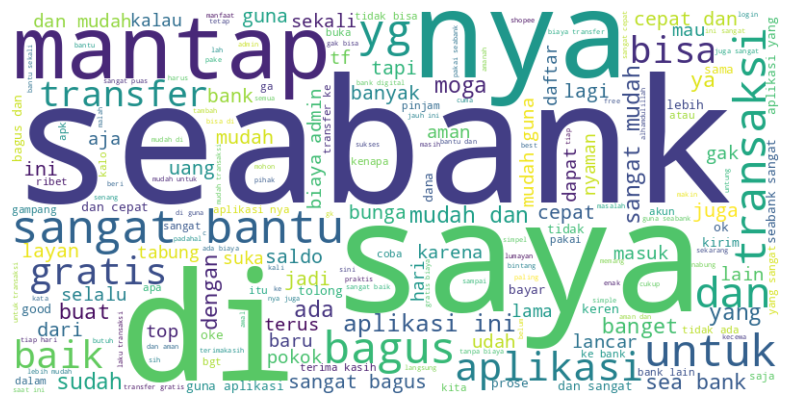

In [ ]:
#wordcloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text_column)

# Menampilkan word cloud menggunakan matplotlib
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()


In [ ]:
# Mendapatkan frekuensi kata dari word cloud
word_freq = wordcloud.words_

# Mengurutkan frekuensi kata secara menurun
sorted_word_freq = sorted(word_freq.items(), key=lambda x: x[1], reverse=True)

# Membuat array dari kata-kata yang sering muncul
top_words = [word for word, freq in sorted_word_freq]

# Menampilkan array kata-kata yang sering muncul
print(top_words)


['seabank', 'saya', 'di', 'nya', 'mantap', 'sangat bantu', 'untuk', 'bagus', 'transaksi', 'yg', 'dan', 'aplikasi', 'gratis', 'baik', 'bisa', 'transfer', 'aplikasi ini', 'moga', 'sudah', 'sangat mudah', 'ada', 'yang', 'mudah dan', 'buat', 'banget', 'dengan', 'ya', 'sea bank', 'sangat bagus', 'cepat', 'lagi', 'banyak', 'juga', 'ini', 'dari', 'jadi', 'saldo', 'tapi', 'mudah', 'bank', 'cepat dan', 'guna', 'uang', 'layan', 'bunga', 'lancar', 'biaya admin', 'baru', 'dan mudah', 'dapat', 'karena', 'terus', 'aman', 'sekali', 'selalu', 'tf', 'aja', 'mau', 'masuk', 'top', 'lain', 'gak', 'pokok', 'udah', 'mudah guna', 'lama', 'tabung', 'kalau', 'nyaman', 'daftar', 'suka', 'hari', 'guna aplikasi', 'dan cepat', 'dan sangat', 'bayar', 'prose', 'ok', 'seabank sangat', 'tidak', 'oke', 'keren', 'sama', 'good', 'lebih', 'kirim', 'dana', 'bagus dan', 'aplikasi yang', 'tolong', 'aplikasi nya', 'atau', 'akun', 'apa', 'ke bank', 'itu', 'ribet', 'kenapa', 'terima kasih', 'transfer ke', 'coba', 'ga', 'gampang

# Menghapus Stopword Pilihan

In [ ]:
# Daftar kata stopword tambahan
additional_stopwords = ['seabank']
# Ambil daftar stopwords bahasa Indonesia dari NLTK
stop_words = set(stopwords.words('indonesian'))

# Tambahkan kata-kata stopword tambahan ke dalam set stop_words
stop_words.update(additional_stopwords)

# Lakukan stopword removal pada kolom 'Tweet_tokens' dan simpan hasilnya pada kolom 'Tweet_stopword'
df['content_stopword'] = df['content_tokens'].apply(lambda words: [word for word in words if word.lower() not in stop_words])

# Tampilkan DataFrame yang sudah diperbarui
df


,content,content_casefolding,content_remove_punct,content_tokens,content_stemming,content_normalisasi,content_stopword
0,sangat baik,sangat baik,sangat baik,"[sangat, baik]","[sangat, baik]",sangat baik,[]
1,TOP,top,top,[top],[top],top,[top]
2,aplikasi ini sudah akses bagi saya yang penyan...,aplikasi ini sudah akses bagi saya yang penyan...,aplikasi ini sudah akses bagi saya yang penyan...,"[aplikasi, ini, sudah, akses, bagi, saya, yang...","[aplikasi, ini, sudah, akses, bagi, saya, yang...",aplikasi ini sudah ak bagi saya yang sandang d...,"[aplikasi, akses, penyandang, disabilitas, netra]"
3,mantap,mantap,mantap,[mantap],[mantap],mantap,[mantap]
4,Terbaik dan memberikan kepuasan ya bagi para p...,terbaik dan memberikan kepuasan ya bagi para p...,terbaik dan memberikan kepuasan ya bagi para p...,"[terbaik, dan, memberikan, kepuasan, ya, bagi,...","[baik, dan, beri, puas, ya, bagi, para, guna, ...",baik dan beri puas ya bagi para guna nyaselain...,"[terbaik, kepuasan, ya, pengguna, nyaselain, m..."
...,...,...,...,...,...,...,...
3479,simple gratis,simple gratis,simple gratis,"[simple, gratis]","[simple, gratis]",simple gratis,"[simple, gratis]"
3480,"sejauh ini ga ada masalah...aman, gampang dah ...","sejauh ini ga ada masalah...aman, gampang dah ...",sejauh ini ga ada masalahaman gampang dah mudah,"[sejauh, ini, ga, ada, masalahaman, gampang, d...","[jauh, ini, ga, ada, masalahaman, gampang, dah...",jauh ini ga ada masalahaman gampang dah mudah,"[ga, masalahaman, gampang, dah, mudah]"
3481,transaksi cepat dan akurat,transaksi cepat dan akurat,transaksi cepat dan akurat,"[transaksi, cepat, dan, akurat]","[transaksi, cepat, dan, akurat]",transaksi cepat dan akurat,"[transaksi, cepat, akurat]"
3482,pelayanan sangat baik cepat. ngk kalah sama ba...,pelayanan sangat baik cepat. ngk kalah sama ba...,pelayanan sangat baik cepat ngk kalah sama ban...,"[pelayanan, sangat, baik, cepat, ngk, kalah, s...","[layan, sangat, baik, cepat, ngk, kalah, sama,...",layan sangat baik cepat ngk kalah sama bank la...,"[pelayanan, cepat, ngk, kalah, bank, bunga, ca..."


# Normalisasi kedua

In [ ]:
# Normalisasi pada kolom teks
lemmatizer = WordNetLemmatizer()
df['content_normalisasi2'] = df['content_stopword'].apply(lambda word_list: ' '.join([lemmatizer.lemmatize(word) for word in word_list]))
df

,content,content_casefolding,content_remove_punct,content_tokens,content_stemming,content_normalisasi,content_stopword,content_normalisasi2
0,sangat baik,sangat baik,sangat baik,"[sangat, baik]","[sangat, baik]",sangat baik,[],
1,TOP,top,top,[top],[top],top,[top],top
2,aplikasi ini sudah akses bagi saya yang penyan...,aplikasi ini sudah akses bagi saya yang penyan...,aplikasi ini sudah akses bagi saya yang penyan...,"[aplikasi, ini, sudah, akses, bagi, saya, yang...","[aplikasi, ini, sudah, akses, bagi, saya, yang...",aplikasi ini sudah ak bagi saya yang sandang d...,"[aplikasi, akses, penyandang, disabilitas, netra]",aplikasi ak penyandang disabilitas netra
3,mantap,mantap,mantap,[mantap],[mantap],mantap,[mantap],mantap
4,Terbaik dan memberikan kepuasan ya bagi para p...,terbaik dan memberikan kepuasan ya bagi para p...,terbaik dan memberikan kepuasan ya bagi para p...,"[terbaik, dan, memberikan, kepuasan, ya, bagi,...","[baik, dan, beri, puas, ya, bagi, para, guna, ...",baik dan beri puas ya bagi para guna nyaselain...,"[terbaik, kepuasan, ya, pengguna, nyaselain, m...",terbaik kepuasan ya pengguna nyaselain manfaat...
...,...,...,...,...,...,...,...,...
3479,simple gratis,simple gratis,simple gratis,"[simple, gratis]","[simple, gratis]",simple gratis,"[simple, gratis]",simple gratis
3480,"sejauh ini ga ada masalah...aman, gampang dah ...","sejauh ini ga ada masalah...aman, gampang dah ...",sejauh ini ga ada masalahaman gampang dah mudah,"[sejauh, ini, ga, ada, masalahaman, gampang, d...","[jauh, ini, ga, ada, masalahaman, gampang, dah...",jauh ini ga ada masalahaman gampang dah mudah,"[ga, masalahaman, gampang, dah, mudah]",ga masalahaman gampang dah mudah
3481,transaksi cepat dan akurat,transaksi cepat dan akurat,transaksi cepat dan akurat,"[transaksi, cepat, dan, akurat]","[transaksi, cepat, dan, akurat]",transaksi cepat dan akurat,"[transaksi, cepat, akurat]",transaksi cepat akurat
3482,pelayanan sangat baik cepat. ngk kalah sama ba...,pelayanan sangat baik cepat. ngk kalah sama ba...,pelayanan sangat baik cepat ngk kalah sama ban...,"[pelayanan, sangat, baik, cepat, ngk, kalah, s...","[layan, sangat, baik, cepat, ngk, kalah, sama,...",layan sangat baik cepat ngk kalah sama bank la...,"[pelayanan, cepat, ngk, kalah, bank, bunga, ca...",pelayanan cepat ngk kalah bank bunga cair hti


# Clean Data dan Simpan Data

In [ ]:
df.drop(df.columns[[0,1,2,3,4,5,6]], axis = 1, inplace = True)
df.head()

,content_normalisasi2
0,
1,top
2,aplikasi ak penyandang disabilitas netra
3,mantap
4,terbaik kepuasan ya pengguna nyaselain manfaat...


In [ ]:
df = df.rename(columns={'content_normalisasi2': 'content'})
df

,content
0,
1,top
2,aplikasi ak penyandang disabilitas netra
3,mantap
4,terbaik kepuasan ya pengguna nyaselain manfaat...
...,...
3479,simple gratis
3480,ga masalahaman gampang dah mudah
3481,transaksi cepat akurat
3482,pelayanan cepat ngk kalah bank bunga cair hti


In [ ]:
# Menyimpan data yang telah dibersihkan
df.to_csv('/content/drive/MyDrive/DataFix/SastrawiProssedSeabank.csv', index=False)